# Compliant wedge demonstration

This notebook compares **compliant-wedge** and **homogeneous half-space** Green's functions for the same GeoSlip2D interface geometry.

## Learning goals
- Build two Green's-function kernels on a shared geometry and observation grid.
- Forward model uniform backslip and compare predicted surface velocities.
- Generate synthetic observations from the compliant-wedge model.
- Invert the same synthetic data with both operators and compare fit and recovered slip.

## Physical setup
The compliant wedge model contains three elastic regions with homogeneous properties:
- accretionary wedge with shear modulus $\mu_w$
- continental crust with shear modulus $\mu_c$
- subducting slab with shear modulus $\mu_s$

## Prerequisites
- `geoslip2d`, `numpy`, and `matplotlib` are available in your active Python environment.
- Run this notebook from the GeoSlip2D repository (or one level below) so paths resolve correctly.

## Suggested run order
1. Run all cells once from top to bottom.
2. For parameter experiments, rerun from the section you changed through the end.
3. If geometry or wedge parameters change, rerun from Section 1.

![Interface Geometry](./images/wedge_interface.png)

## Imports and setup

This section imports required libraries, loads helper routines, and resolves output paths.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import geoslip2d as gs2d

# Helper routines for forward modeling, plotting, and inversion comparison.
from geoslip2d.notebook_helpers import (
    make_synthetic_observations,
    patch_center_depths,
    patch_center_x,
    plot_inversion_results,
    plot_surface_velocities,
    run_pair_inversions,
    surface_velocity,
    uniform_backslip_above_depth,
)

# Resolve project root robustly whether running from repo root or notebook folder.
cwd = Path.cwd().resolve()
if (cwd / "src" / "geoslip2d").is_dir():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent

OUTPUT_DIR = PROJECT_ROOT / "examples" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")

PROJECT_ROOT = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D_development/2026_Geodesy_TSC/notebooks/Day3
OUTPUT_DIR   = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D_development/2026_Geodesy_TSC/notebooks/Day3/examples/outputs


## 1. Shared interface geometry and observation grid

Both model backends in this notebook use the same `InterfaceGeometry` and the same surface observation coordinates `xobs`.

What to check here:
- Interface geometry is reasonable.
- Observation window covers the profile region you want to compare.

InterfaceGeometry(n_patch=49, x=[0, 240] km, z=[-0, 45.8] km)


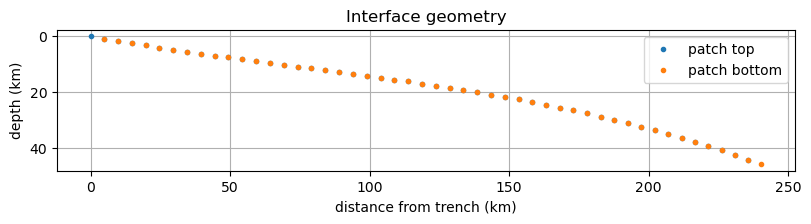

In [2]:
# Shared interface and observation grid used by both model backends.
faultdip_trench = 10.0
faultdip_bottom = 20.0
x_trench = 0.0
x_bottom = 238.0
z_bottom = 45.0
patch_length = 5.0

# Surface observation coordinates (km).
xobs = np.linspace(150, 500.0, 300)

interface = gs2d.make_interface_geometry_legacy(
    faultdip_trench=faultdip_trench,
    x_trench=x_trench,
    x_bottom=x_bottom,
    faultdip_bottom=faultdip_bottom,
    z_bottom=z_bottom,
    patch_length=patch_length,
)
print(interface.summary())
fig = gs2d.plot_interface(interface)
plt.show()

## 2. Build homogeneous and compliant-wedge Green's functions

This section builds two operators on the same geometry and `xobs` grid:

- Homogeneous: reference elastic half-space model.
- Compliant wedge: three-region wedge model with contrast in shear modulus.

Interpretation note: differences between predictions come from Earth-structure assumptions, not geometry differences.

completed 1 of 49 patches
completed 2 of 49 patches
completed 3 of 49 patches
completed 4 of 49 patches
completed 5 of 49 patches
completed 6 of 49 patches
completed 7 of 49 patches
completed 8 of 49 patches
completed 9 of 49 patches
completed 10 of 49 patches
completed 11 of 49 patches
completed 12 of 49 patches
completed 13 of 49 patches
completed 14 of 49 patches
completed 15 of 49 patches
completed 16 of 49 patches
completed 17 of 49 patches
completed 18 of 49 patches
completed 19 of 49 patches
completed 20 of 49 patches
completed 21 of 49 patches
completed 22 of 49 patches
completed 23 of 49 patches
completed 24 of 49 patches
completed 25 of 49 patches
completed 26 of 49 patches
completed 27 of 49 patches
completed 28 of 49 patches
completed 29 of 49 patches
completed 30 of 49 patches
completed 31 of 49 patches
completed 32 of 49 patches
completed 33 of 49 patches
completed 34 of 49 patches
completed 35 of 49 patches
completed 36 of 49 patches
completed 37 of 49 patches
completed 

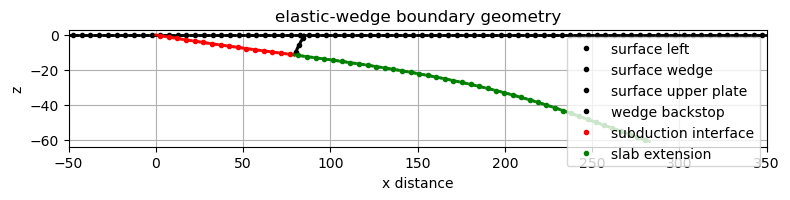

In [3]:
# Build homogeneous reference Green's functions.
greens_hom = gs2d.build_greens(
    "homogeneous",
    interface,
    xobs,
    length_override=patch_length,
    progress=True,
)

# Build compliant-wedge Green's functions.
# sync_geometry_from_interface=True keeps wedge geometry consistent with Section 1 interface.
wedge_cfg = gs2d.WedgeConfig(
    wedge_bot=12.0,
    wedge_top_x=90.0,
    L_slab=50.0,
    W=200.0,
    mu1=1.0,
    mu2=0.1,   # compliant wedge
    mu3=10.0,
    nu=0.25,
    sync_geometry_from_interface=True,
    progress=True,
    verbose=True,
)

gs2d.plot_wedge_geometry(config=wedge_cfg, interface=interface, xlim=(-50, 350))

greens_nonhom = gs2d.build_greens(
    "wedge",
    interface,
    xobs,
    wedge_cfg,
)

## 3. Forward model: uniform backslip above locking depth

This section applies a simple synthetic slip model to both operators and compares predicted surface velocities.

Use this as an intuition-building step before inversion.

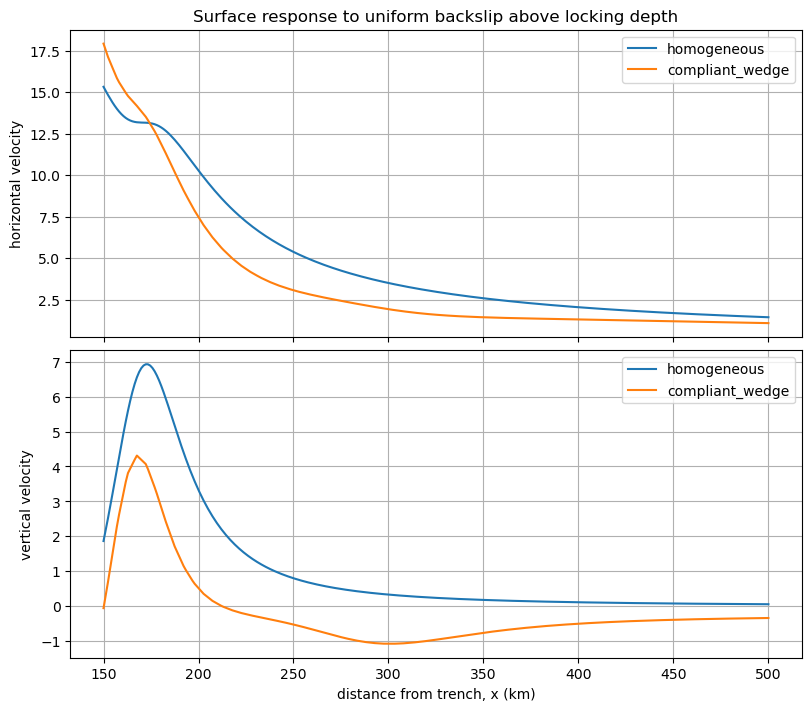

In [4]:
# Uniform backslip above locking depth (reference forward model).
locking_depth_km = 25.0

slip_hom = uniform_backslip_above_depth(greens_hom, locking_depth_km, backslip_rate=30)
slip_nonhom = uniform_backslip_above_depth(greens_nonhom, locking_depth_km, backslip_rate=30)

vel_hom = surface_velocity(greens_hom, slip_hom)
vel_nonhom = surface_velocity(greens_nonhom, slip_nonhom)

fig = plot_surface_velocities(xobs, vel_hom, vel_nonhom, "compliant_wedge")
plt.show()

## 4. Synthetic inversion and model comparison

Synthetic data are generated from the **compliant_wedge** model and inverted twice:

- with homogeneous Green's functions
- with compliant-wedge Green's functions

Interpretation tips:
- Compare WRMS values to assess data fit.
- Compare recovered slip against the known truth model.
- Regularization (`alpha`) and solver settings influence smoothness and amplitude of recovered slip.

Homogeneous inversion WRMS:     1.354
Non-homogeneous inversion WRMS: 0.928


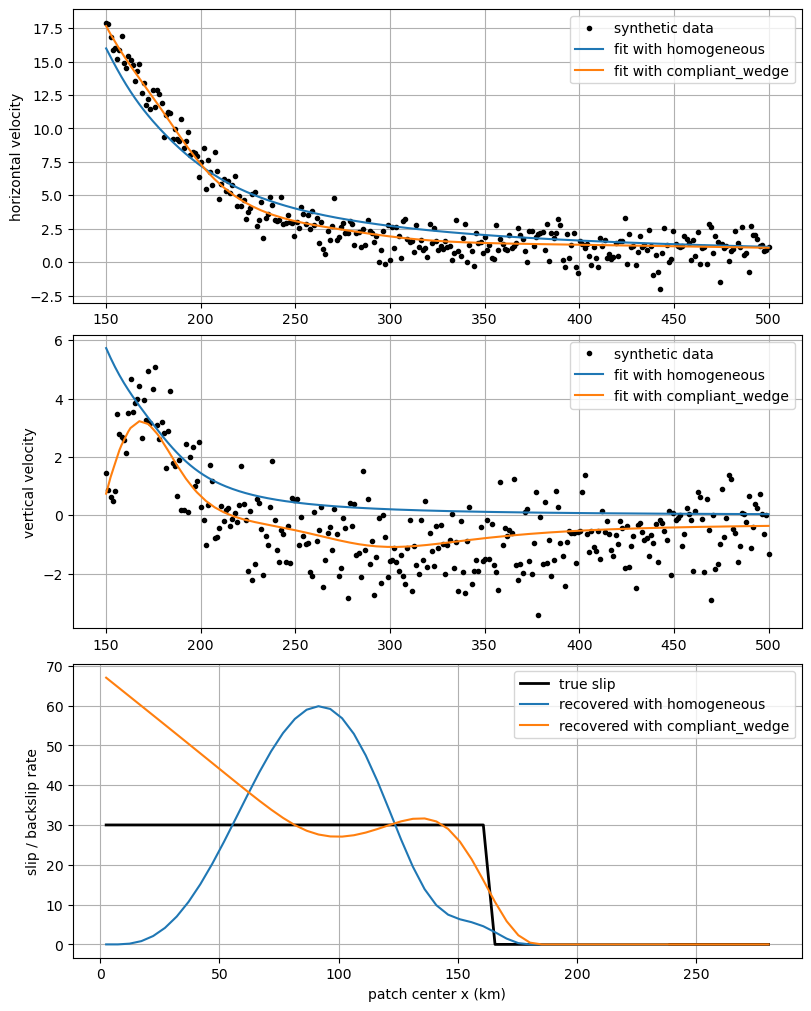

In [5]:
# Generate synthetic observations from the compliant-wedge model truth.
truth_slip = slip_nonhom.copy()
observations = make_synthetic_observations(
    greens_nonhom,
    truth_slip,
    sigma_h=1,  # mm/yr standard deviation for horizontal noise
    sigma_v=1,  # mm/yr standard deviation for vertical noise
    noise=True,
)

# Inversion configuration: tune regularization and solver constraints here.
cfg = gs2d.SlipInversionConfig(
    alpha=1,
    smoothing_order="second",
    solver_type="nonnegative",
    inversion_mode="slip_deficit",
    use_vertical=True,
)

# Invert the same observations with both operators and compare results.
out_hom = gs2d.fit_profile_slip(observations, greens_hom, cfg)
out_nonhom = gs2d.fit_profile_slip(observations, greens_nonhom, cfg)
print(f"Homogeneous inversion WRMS:     {out_hom['wrms']:.3f}")
print(f"Non-homogeneous inversion WRMS: {out_nonhom['wrms']:.3f}")

fig = plot_inversion_results(
    greens_hom,
    greens_nonhom,
    truth_slip,
    out_hom,
    out_nonhom,
    "compliant_wedge",
)
plt.show()